In [34]:
import numpy as np
from scipy.linalg import eig, eigh
import matplotlib.pyplot as plt

# 1.
Las ecuaciones algebraicas lineales pueden surgir en la solución de ecuaciones diferenciales. Por ejemplo, la siguiente ecuación diferencial se obtiene de un balance de calor para una varilla larga y delgada:

$$
\frac{d^2 T}{d x^2} + h'(T_a - T) = 0
$$

donde:
- $T$ = temperatura (°C)
- $x$ = distancia a lo largo de la varilla (m)
- $h'$ = coeficiente de transferencia de calor entre la varilla y el aire ambiente ($m^{-2}$)
- $T_a$ = temperatura del aire circundante (°C)

Esta ecuación puede transformarse en un sistema de ecuaciones algebraicas lineales usando una aproximación por diferencias finitas para la segunda derivada:

$$
\frac{d^2 T}{d x^2} = \frac{T_{i+1} - 2T_i + T_{i-1}}{\Delta x^2}
$$

donde $T_i$ designa la temperatura en el nodo $i$. Sustituyendo en la ecuación diferencial:

$$
-T_{i-1} + (2 + h' \Delta x^2) T_i - T_{i+1} = h' \Delta x^2 T_a
$$


Esta ecuación puede escribirse para cada uno de los nodos interiores de la varilla, resultando en un sistema tridiagonal de ecuaciones. Los nodos en los extremos de la varilla están fijos por condiciones de frontera.
    
- Desarrolle una solución numérica para una varilla de 10 m con $T_a = 10$, $T(x=0) = 40$, $T(x=10) = 200$ y $h' = 0.02$. Utilizando una solución por diferencias finitas con cuatro nodos interiores como se muestra en la Figura ($\Delta x = 2$ m).

<center>

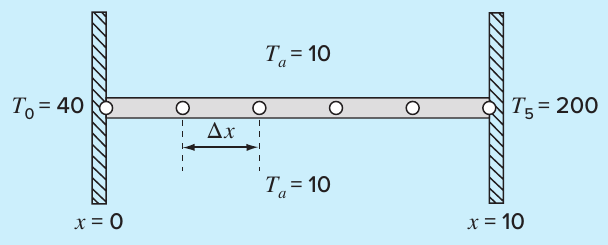

</center>


In [35]:
# Parámetros dados
h_prime = 0.02
Ta = 10
T0 = 40  # T en x=0
T5 = 200  # T en x=10 (nodo 5)
delta_x = 2
n = 4  # número de nodos interiores

# Construir el sistema tridiagonal
A = np.zeros((n, n))
b = np.zeros(n)

# Coeficiente principal
main_diag = 2 + h_prime * delta_x**2

# Llenar la matriz A y el vector b
for i in range(n):
    A[i, i] = main_diag
    if i > 0:
        A[i, i-1] = -1
    if i < n-1:
        A[i, i+1] = -1
    
    b[i] = h_prime * delta_x**2 * Ta

# Ajustar las condiciones de frontera
b[0] += T0  # Agregar T0 al primer nodo
b[-1] += T5  # Agregar T5 al último nodo

# Resolver el sistema
T_interior = np.linalg.solve(A, b)

# Crear el vector completo de temperaturas
T = np.zeros(n+2)
T[0] = T0
T[-1] = T5
T[1:-1] = T_interior

# Posiciones de los nodos
x = np.linspace(0, 10, n+2)

# Mostrar resultados
print("Solución numérica:")
print(f"Nodos (x): {x}")
print(f"Temperaturas (T): {T}")

Solución numérica:
Nodos (x): [ 0.  2.  4.  6.  8. 10.]
Temperaturas (T): [ 40.          59.73889169  83.45689471 113.05144932 150.89011986
 200.        ]


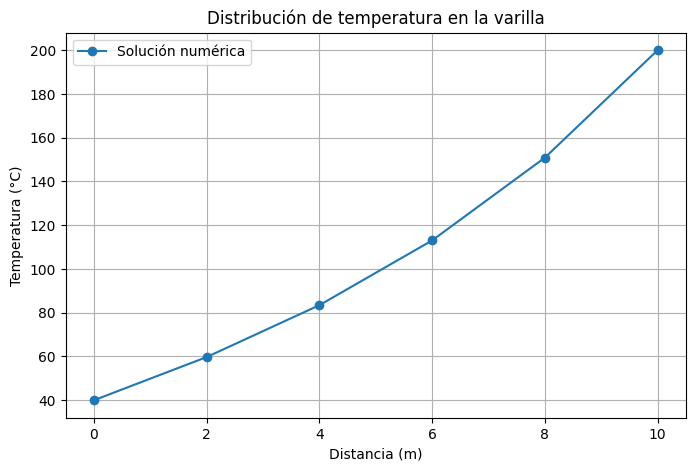

In [36]:
# Graficar
plt.figure(figsize=(8, 5))
plt.plot(x, T, 'o-', label='Solución numérica')
plt.xlabel('Distancia (m)')
plt.ylabel('Temperatura (°C)')
plt.title('Distribución de temperatura en la varilla')
plt.grid(True)
plt.legend()
plt.show()

# 2.
Considere el circuito de la figura. Usando las leyes de Kirchoff escriba las ecuaciones para corriente y voltaje. Luego, determine la forma matricial y encuentre los valores de la corriente que circula por cada nodo, es decir, $i_{12}$, $i_{23}$ y asi sucesivamente.

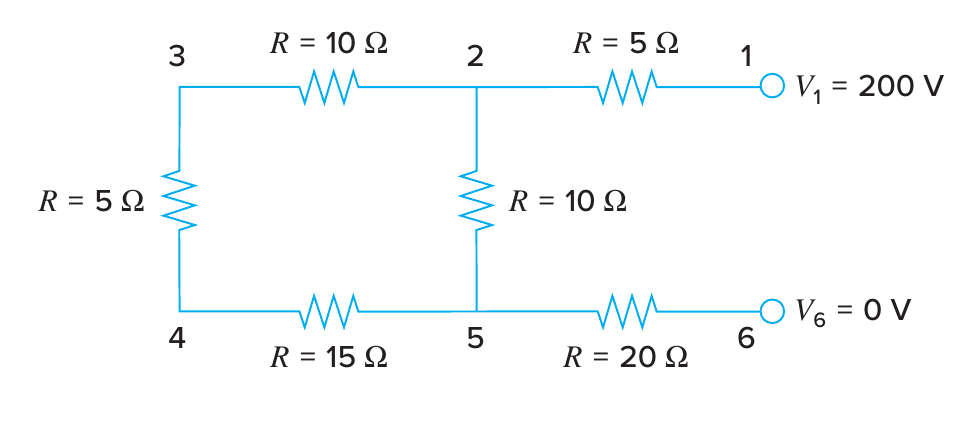

$$i_{12}-i_{23}-i_{25}=0$$
$$i_{23}-i_{34}=0$$
$$i_{34}-i_{45}=0$$
$$i_{45}-i_{25}-i_{56}=0$$
$$R_1 i_{12}+R_5 i_{25}+R_6 i_{56}=200$$
$$R_5 i_{25}-R_2 i_{23}-R_3 i_{34}-R_4 i_{45}=0$$

In [37]:
# Definir los valores de los resistores y las fuentes de voltaje
R1=5  # Ohm
R2=10  # Ohm
R3=5  # Ohm
R4=15  # Ohm
R5=10   # Ohm
R6=20 # Ohm
V1=200 # En voltios

# Definir la matriz de coeficientes (A) y el vector de términos independientes (B)

A = np.array([
    [1, -1, 0, 0, 0, -1],   #Nodo 1
    [0, 1, -1, 0, 0, 0],   # Nodo 2
    [0, 0, 1, -1, 0, 0], # Nodo 3
    [0, 0 , 0 , 1 , -1 , 1], #Nodo 4    
    [R1, 0, 0, 0, R6,R5],  #Malla 1 
    [0, -R2, -R3, -R4, 0, R5] #Malla 2   
])

B = np.array([0, 0, 0,0, V1,0])

# Resolver el sistema de ecuaciones lineales
corrientes = np.linalg.solve(A, B)

# Mostrar los resultados
i12, i23, i34, i45, i56, i25 = corrientes
print(f"Corriente i12: {i12:.3f} A")
print(f"Corriente i23: {i23:.3f} A")
print(f"Corriente i34: {i34:.3f} A")
print(f"Corriente i45: {i45:.3f} A")
print(f"Corriente i56: {i56:.3f} A")
print(f"Corriente i25: {i25:.3f} A")

Corriente i12: 6.154 A
Corriente i23: 1.538 A
Corriente i34: 1.538 A
Corriente i45: 1.538 A
Corriente i56: 6.154 A
Corriente i25: 4.615 A


# 3.

Considere una partícula cuyo Hamiltoniano es $ H = \begin{pmatrix} 2 & i & 0 \\ -i & 1 & 1 \\ 0 & 1 & 0 \end{pmatrix} $.

- ¿Es $H$ hermítica?

- Encuentre los valores propios (Energía) y los vectores propios normalizados de $H$.


In [38]:
# Definir la matriz H
H = np.array([[2, 1j, 0],
              [-1j, 1, 1],
              [0, 1, 0]], dtype=complex)

# Verificar si H es hermítica
H_dagger = np.conj(H).T
es_hermitica = np.allclose(H, H_dagger)


print("¿Es H hermítica?", es_hermitica)

¿Es H hermítica? True


In [39]:
# Calcular valores y vectores propios
eigenvalues, eigenvectors = np.linalg.eigh(H)  # eigh es para matrices hermitianas

print("Valores propios (Energías):")
print(eigenvalues)

print("Vectores propios normalizados (columnas):")
print(eigenvectors)

Valores propios (Energías):
[-0.73205081  1.          2.73205081]
Vectores propios normalizados (columnas):
[[-0.21132487+0.j          0.57735027-0.j         -0.78867513+0.j        ]
 [ 0.        -0.57735027j  0.        +0.57735027j  0.        +0.57735027j]
 [ 0.        +0.78867513j  0.        +0.57735027j  0.        +0.21132487j]]


In [40]:
# Verificar normalización
print("Verificación de normalización:")
for i in range(3):
    norm = np.linalg.norm(eigenvectors[:, i])
    print(f"Vector {i+1}: norma = {norm:.6f}")

Verificación de normalización:
Vector 1: norma = 1.000000
Vector 2: norma = 1.000000
Vector 3: norma = 1.000000


# 4.

Considere el sistema masa-resorte mostrado en la figura. 

<center>

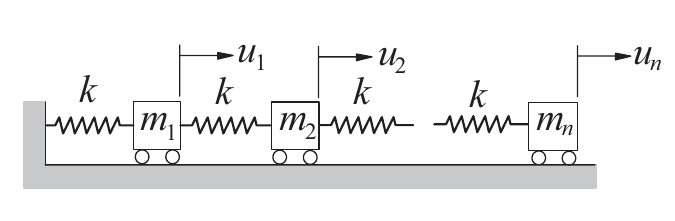

</center>


Las ecuaciones diferenciales que gobiernan el sistema masa-resorte son:

$$
k(-2u_1 + u_2) = m_1 \ddot{u}_1
$$

$$
k(u_{i-1} - 2u_i + u_{i+1}) = m_i \ddot{u}_i \quad (i = 2, 3, \ldots, n-1)
$$

$$
k(u_{n-1} - u_n) = m_n \ddot{u}_n
$$

donde:
- $u_i(t)$ representa el desplazamiento de la masa $i$ desde su posición de equilibrio
- $k$ es la constante de rigidez del resorte
- $m_i$ es la masa del elemento $i$-ésimo

Dados los valores de $k$ y el vector de masas $\mathbf{m} = \begin{bmatrix} m_1 & m_2 & \cdots & m_n \end{bmatrix}^T$, se requiere escribir un programa que calcule las 2 frecuencias más bajas del sistema y calcular los desplazamientos relativos correspondientes de las masas

Parámetros:
- $k = 500\,\text{kN/m}$
- $\mathbf{m} = \begin{bmatrix} 1.0 & 1.0 & 1.0 & 8.0 & 1.0 & 1.0 & 8.0 \end{bmatrix}^T \text{kg}$

In [41]:
def calcular_frecuencias_masa_resorte(k, masas):
    """
    Calcula las frecuencias más bajas y los modos de vibración para un sistema masa-resorte.
    
    Parámetros:
    k - constante del resorte (en N/m)
    masas - array de masas (en kg)
    
    Retorna:
    frecuencias - array de frecuencias (en rad/s) ordenadas de menor a mayor
    modos - matriz donde cada columna es un modo de vibración normalizado
    """
    n = len(masas)
    
    # Construir la matriz K
    K = np.zeros((n, n))
    for i in range(n):
        if i == 0:
            K[i, i] = 2*k
            K[i, i+1] = -k
        elif i == n-1:
            K[i, i] = k
            K[i, i-1] = -k
        else:
            K[i, i-1] = -k
            K[i, i] = 2*k
            K[i, i+1] = -k
    
    # Construir la matriz de masa M (diagonal)
    M = np.diag(masas)
    
    # Resolver el problema generalizado de valores propios: K v = w² M v
    valores_propios, modos = eigh(K, M)
    
    # Calcular frecuencias en rad/s 
    frecuencias = np.sqrt(valores_propios) 
    
    return frecuencias, modos

# Parámetros del problema
k = 500e3  # 500 kN/m a N/m
masas = np.array([1.0, 1.0, 1.0, 8.0, 1.0, 1.0, 8.0])  # kg

# Calcular frecuencias y modos
frecuencias, modos = calcular_frecuencias_masa_resorte(k, masas)


In [42]:
# Tomamos las dos frecuencias más bajas
frecuencias=frecuencias[0:2]
modos=modos[:,0:2]

In [43]:
print("Dos frecuencias más bajas rad/s:")
for i, freq in enumerate(frecuencias):
    print(f"Frecuencia {i+1}: {freq:.4f} rad/s")

Dos frecuencias más bajas rad/s:
Frecuencia 1: 74.2689 rad/s
Frecuencia 2: 215.3065 rad/s


In [44]:
print("Modos de vibración correspondientes (desplazamientos relativos):")
for i in range(modos.shape[1]):
    print(f"\nModo {i+1}:")
    for j, desplazamiento in enumerate(modos[:, i]):
        print(f"Masa {j+1}: {desplazamiento:.4f}")

Modos de vibración correspondientes (desplazamientos relativos):

Modo 1:
Masa 1: 0.0486
Masa 2: 0.0967
Masa 3: 0.1437
Masa 4: 0.1892
Masa 5: 0.2179
Masa 6: 0.2443
Masa 7: 0.2679

Modo 2:
Masa 1: 0.0834
Masa 2: 0.1591
Masa 3: 0.2200
Masa 4: 0.2606
Masa 5: 0.1078
Masa 6: -0.0549
Masa 7: -0.2126


# 5.
<center>

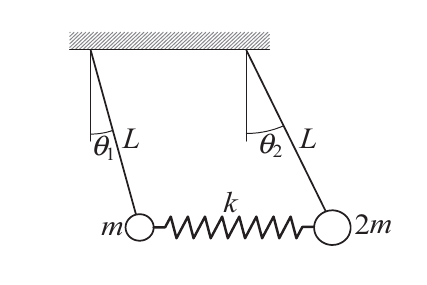

</center>

Los dos péndulos están conectados por un resorte que no está deformado cuando los péndulos están en posición vertical. Las ecuaciones de movimiento del sistema pueden expresarse como:

$$kL(\theta_2 - \theta_1) - mg\theta_1 = mL\ddot{\theta}_1$$

$$-kL(\theta_2 - \theta_1) - 2mg\theta_2 = 2mL\ddot{\theta}_2$$

donde $\theta_1$ y $\theta_2$ son los desplazamientos angulares y $k$ es la rigidez del resorte. Determine las frecuencias de vibración y las amplitudes relativas de los desplazamientos angulares. Utilice los valores $m = 0.25 \, \text{kg}$, $k = 20 \, \text{N/m}$, $L = 0.75 \, \text{m}$ y $g = 9.8 \, \text{m/s}^2$.
